<a href="https://colab.research.google.com/github/Matheus0820/Aprendizado-de-Maquina/blob/main/unidade01/codes/Pr%C3%A1tica_da_aula_de_Arvore_de_Decisao_Aprendizado_de_maquina.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

url = 'https://raw.githubusercontent.com/ect-info/ml/master/dados/diabetes.csv'
df = pd.read_csv(url)

print('DataFrame loaded successfully:')

df.head()

DataFrame loaded successfully:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### Entradas:
- Glucose
- BloodPressure
- Insulin
- Age

### Saída:
- Outcome

In [ ]:
# Pegando a matriz X
colunas_seletionadas = ['Glucose', 'BloodPressure', 'Insulin', 'Age']
X = df[colunas_seletionadas].values
print(X[:4])

[[148  72   0  50]
 [ 85  66   0  31]
 [183  64   0  32]
 [ 89  66  94  21]]


In [ ]:
# Pegando o array y
y = df['Outcome'].values
print(y[:4])

[1 0 1 0]


# Divisão entre dados de treinamento e de teste
usaremos o modulo do sklearn ->

```
from sklearn.model_selection import train_test_split
```



In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

X_train: (614, 4)
X_test: (154, 4)
y_train: (614,)
y_test: (154,)


# Treinamento

In [ ]:
# Importando a biblioteca do sklearn da árvore de decisão
from sklearn.tree import DecisionTreeClassifier

# Ele cria um classificador de arvore de decisão com profundidade máxima de 3 critérios
clf = DecisionTreeClassifier(max_depth=3, criterion='entropy') # Definindo o critério de entropia

# Treinar o classificador
clf.fit(X_train, y_train)


DecisionTreeClassifier(criterion='entropy', max_depth=3)

# Mostrando o Diagrama da Árvore treinada

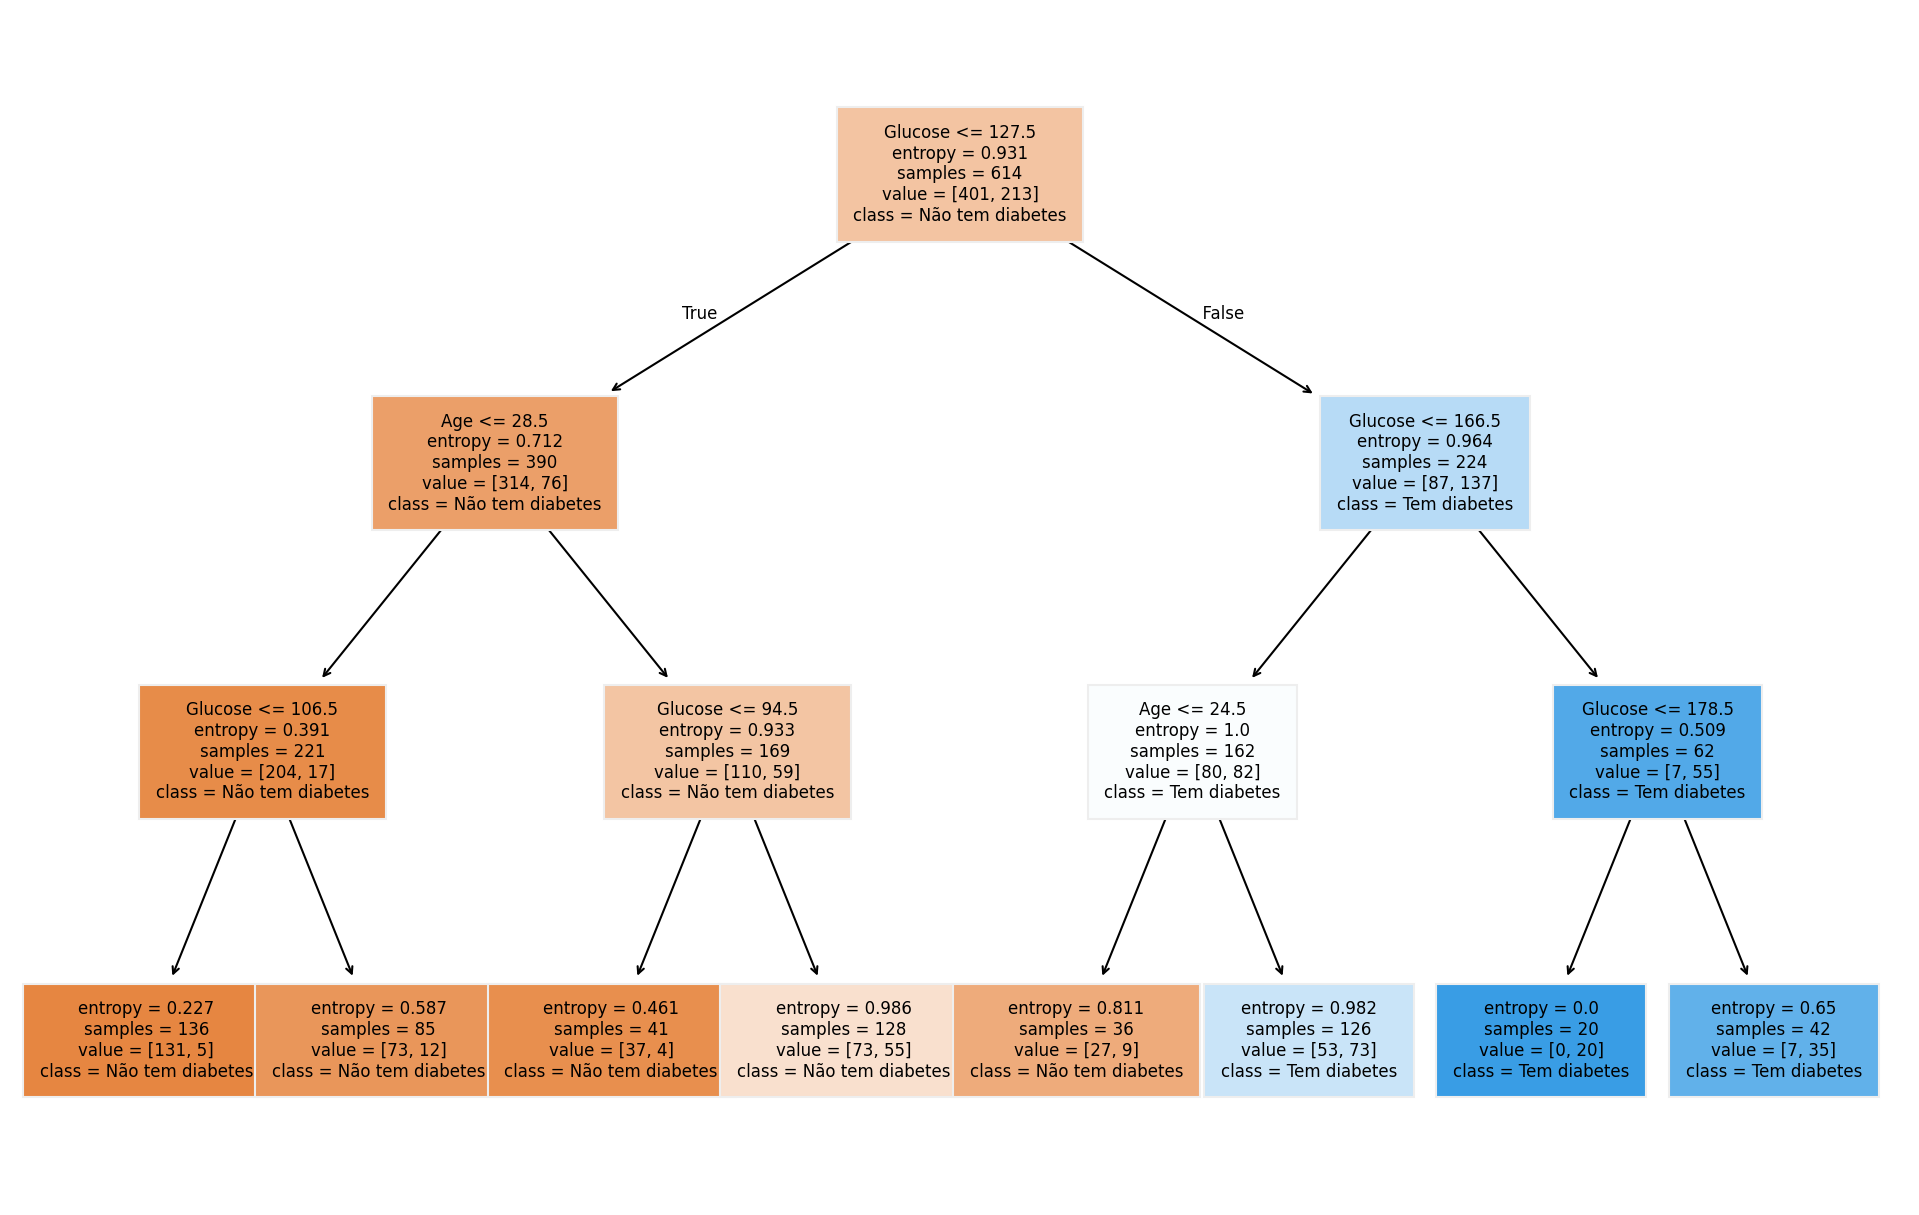

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Definir o estilo do gráfico
plt.style.use("ggplot")

# Plotar a árvore de decisão
fig, axes = plt.subplots(nrows = 1, ncols = 1, figsize = (8,5), dpi=300)
plot_tree(clf,
          feature_names=['Glucose', 'BloodPressure', 'Insulin', 'Age'],
          class_names=['Não tem diabetes', 'Tem diabetes'],
          filled=True,
          node_ids=False,
          fontsize=4)
plt.show()

# Avaliando o modelo

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix

# Fazer previsões com o dados de teste
y_pred = clf.predict(X_test)

# Calcular a acurácia
acuracia = accuracy_score(y_test, y_pred)
print(f"Acurácia: {acuracia}")

# Calcular a matriz de confusão
matriz_confusao = confusion_matrix(y_test, y_pred)
print("Matriz de confusão:")
print(matriz_confusao)

Acurácia: 0.7532467532467533
Matriz de confusão:
[[82 17]
 [21 34]]
